# Operator Dynamics in Random Bricklayer Circuits with Pauli Propagation

The goal of this notebook is to study the time evolution of a local quantum observable using the Pauli propagation framework implemented in `PauliPropagation.jl`.



In [9]:
#using Pkg; Pkg.add("PauliPropagation")
using PauliPropagation

# 1. Introduction

## 1.1 Validation of Pauli Propagation on Two-Qubit XX Circuits

Before we gonna focus on a simple and controlled setting in order to validate the method and build intuition before moving to more complex random circuits.

We consider a system of $n=2$ qubits arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates** applied in a **bricklayer pattern**.

In [10]:
nqubits = 2

topology = bricklayertopology(nqubits; periodic=false)

1-element Vector{Tuple{Int64, Int64}}:
 (1, 2)

Each layer consists of nearest-neighbor gates of the form:

$$
U_{ij} = e^{-i \theta X_i X_j}
$$

where $X_i$ is the Pauli X operator acting on qubit $i$, and $\theta$ is a fixed parameter (Trotter step).


This type of circuit corresponds to a Trotterized time evolution under an XX Hamiltonian:

$$
H = \sum_{\langle i,j \rangle} X_i X_j
$$

In [11]:
function simple_trotter_circuit_XX(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
      topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
      rxxlayer!(circuit, topology)
    end
    return circuit
end

simple_trotter_circuit_XX (generic function with 1 method)

---

## 1.2 Heisenberg picture

Instead of evolving a quantum state, we study the evolution of an observable $O$ in the Heisenberg picture:

$$
O(t) = U^\dagger O U
$$

In this notebook, we choose as initial observable a local Pauli operator:

$$
O = Z_i
$$

In [12]:
i = 1
Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i

PauliString(nqubits: 2, 1.0 * ZI)

---

## 1.3 Pauli propagation method

The key idea of Pauli propagation is to express the observable as a sum of Pauli strings:

$$
O = \sum_\alpha c_\alpha P_\alpha
$$

and to propagate each Pauli string through the circuit.

Under conjugation by quantum gates, Pauli strings transform into linear combinations of other Pauli strings. This leads to a growth in the number of terms, which is controlled in practice using:

- truncation of small coefficients
- limitation of the Pauli weight

This method is particularly efficient when the operator remains relatively sparse in the Pauli basis.

Here we want to verify the implementation : we don't apply truncation.

In [13]:
# the truncations
max_weight = typemax(Int)   # no limit          in the documentation they put = 6
min_abs_coeff = 0.0         # no truncations                  """             = 1e-4

0.0

We need to pay attention to the values of our truncations to avoid diverging from the exact solutions. We can verify whether our method is always implemented correctly by measuring the norm of the observable, which should be close to 1.

$$\sum_\alpha |c_\alpha|^2 = 1$$

In [14]:
function pauli_norm(pauli_sum::PauliSum)
    return sum(((P, c),) -> abs(c)^2, pauli_sum; init=0.0)
end

pauli_norm (generic function with 1 method)

---

## 1.3 Propagation in the XX Circuit

In [15]:
nlayers = 150
circuit = simple_trotter_circuit_XX(nqubits, nlayers; topology)

dt = 0.1 # time step
parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value

# propagate through the circuit
pauli_sum = propagate(circuit, observable, parameters; max_weight, min_abs_coeff)

PauliSum(nqubits: 2, 2 Pauli terms:
 0.65029 * YX
 -0.75969 * ZI
)

If we calculate the same circuit analytically and compare our results, see [validation_twoQubit_XX_circuit.py](https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/heisenberg-picture/pauli-propagation/validation_twoQubit_XX_circuit.py), we obtain the same result, barring a numerical error of $10^{-6}$ with $150$ evolution steps.

---

# 2. Quantities and measurements

## 2.1 Pauli Entropy

For an observable express as a sum of Pauli strings, we define the Pauli Entropy:

$$ S = - \sum_\alpha |c_\alpha|^2 log(|c_\alpha|^2)$$

In [16]:
function pauli_entropy(pauli_sum::PauliSum)
    return sum(((P, c),) -> c != 0 ? -abs(c)^2 * log(abs(c)^2) : 0.0, pauli_sum; init=0.0)
end

pauli_entropy (generic function with 1 method)

---

## 2.2 Overlap with the intial state $|0\rangle$

$$\langle A \rangle_{\psi(t)} = \langle \psi_0 | U^\dagger A U | \psi_0\rangle = \langle \psi_0 | A(t) | \psi_0\rangle = \langle \psi_0 | \sum_k c_k(t) P_k | \psi_0\rangle$$

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle \psi_0 | P_k | \psi_0\rangle$$

We know :
- $\langle 0 | I | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | Z | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | X | 0 \rangle = \langle 0 | 1 \rangle = 0$
- $\langle 0 | Y | 0 \rangle = i \langle 0 | 1 \rangle = 0$

So if the initial state $| \psi_0 \rangle = |00\dots0\rangle$ :

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle 00\dots0 | P_k | 00\dots0\rangle = \sum_{\alpha} c_\alpha(t)$$

where $\forall \alpha, P_\alpha$ contains **only** the identity $I$ and the operator $Z$.

In [17]:
function decode_pauli(pauli_string, num_qubits::Int)
    mapping = Dict(0b00 => "I", 0b01 => "X", 0b10 => "Y", 0b11 => "Z")

    res = ""
    for i in 0:(num_qubits - 1)
        bits = (pauli_string >> (2 * i)) & 0b11
        res *= mapping[bits]
    end
    return res
end

function compute_evolution(observable::PauliSum)
  result = 0.0
  for (pauli_string, coeff) in observable
      string = decode_pauli(pauli_string, observable.nqubits)
      if !(contains(string, "X") || contains(string, "Y"))
          result += real(coeff)
      end
  end
  return result
end

compute_evolution (generic function with 1 method)

But in this package we have a function `overlapwithzero()` which does exactly the same thing :

In [18]:
overlap1 = compute_evolution(pauli_sum)
overlap2 = overlapwithzero(pauli_sum)

println("The two overlap are close : ", (overlap1 ≈ overlap2))

The two overlap are close : true


---

## 2.3 Propagation layer by layer

We need to see how a certain quantity behaves as it propagates through the circuit, which the `propagation()` function in the package does not allow us to do, since it only gives us the result.

In [19]:
function propagate_layerbylayer(circuit, observable::PauliString, nlayers::Int64, parameters=nothing; max_weight::Integer, min_abs_coeff::Float64)
  ngate_bylayer = size(circuit,1) ÷ nlayers

  overlap, entropy = Float64[], Float64[]
  current = observable

  for i in nlayers:-1:1 # pour propager on a besoin de donner les couches dans le sens inverse /!\
    first_gate_idx = ((i-1)*ngate_bylayer)+1; last_gate_idx = (i * ngate_bylayer)
    layer_gates = circuit[first_gate_idx:last_gate_idx]

    if parameters == nothing
        parameter = nothing
    else
        parameter = parameters[first_gate_idx:last_gate_idx]
    end
    current = propagate(layer_gates, current, parameter; max_weight, min_abs_coeff)

    push!(overlap, overlapwithzero(current))
    push!(entropy, pauli_entropy(current))

    j=nlayers-i
    if j % (nlayers÷10)==0
      if !(pauli_norm(current) ≈ 1)
        println("layer : ",j,"/",nlayers," Break")
        break
      end
      println("layer : ",j,"/",nlayers," complete")
    end
  end

  result = Dict("overlap" => overlap, "S" => entropy)
  return current, result
end

propagate_layerbylayer (generic function with 2 methods)

In [20]:
nqubits = 10
i = 1
Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i

nlayers = 200

circuit = simple_trotter_circuit_XX(nqubits, nlayers; topology)
dt = 0.1 # time step
parameters = ones(countparameters(circuit)) * dt # parameters of all evolution gates take the same value

pauli_sum, result = propagate_layerbylayer(circuit, observable, nlayers, parameters;
                          max_weight, min_abs_coeff)
println(pauli_sum)

pauli_sum2 = propagate(circuit, observable, parameters;
                          max_weight, min_abs_coeff)
println(pauli_sum2)

println("The two pauli sum are close : ", (pauli_sum ≈ pauli_sum2))

layer : 0/200 complete
layer : 20/200 complete
layer : 40/200 complete
layer : 60/200 complete
layer : 80/200 complete
layer : 100/200 complete
layer : 120/200 complete
layer : 140/200 complete
layer : 160/200 complete
layer : 180/200 complete
PauliSum(nqubits: 10, 2 Pauli terms:
 0.91295 * YXIIIIIIII
 0.40808 * ZIIIIIIIII
)
PauliSum(nqubits: 10, 2 Pauli terms:
 0.91295 * YXIIIIIIII
 0.40808 * ZIIIIIIIII
)
The two pauli sum are close : true


This feature now allows us to calculate values based on the circuit layers like : entropy or overlap with the initial state.

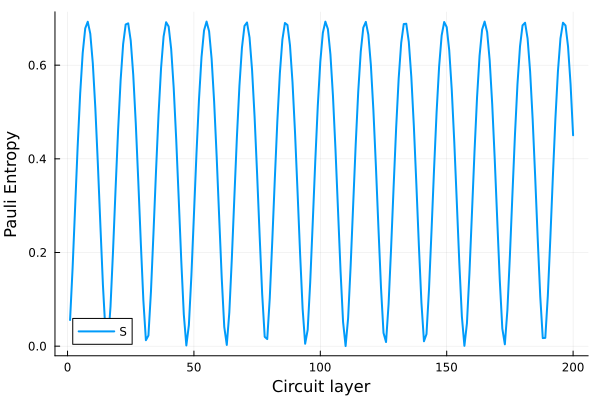

In [21]:
using Plots

entropy = result["S"]
plot(1:nlayers, entropy,
     xlabel="Circuit layer",
     ylabel="Pauli Entropy",
     label="S",
     lw=2)



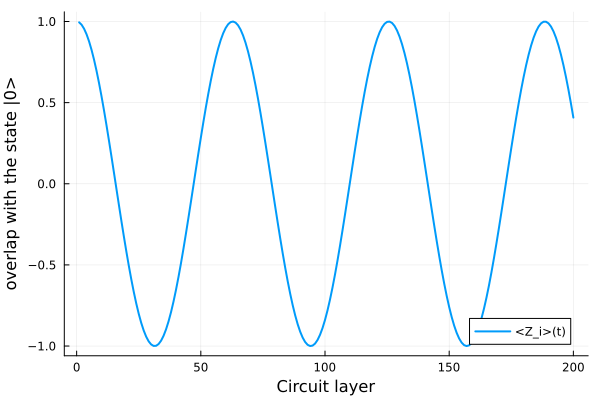

In [22]:
overlap = result["overlap"]
plot(1:nlayers, overlap,
     xlabel="Circuit layer",
     ylabel="overlap with the state |0>",
     label="<Z_i>(t)",
     lw=2)

---

# 3. Random Gate Circuit

In a second stage, we will generalize this setup to random circuits of the form:

$$
U = \prod_j e^{i \theta_j P_j}
$$

where:

- $\theta_j$ are random angles
- $P_j$ are random two-qubit Pauli strings


---

## 3.1 Decomposition of a 4x4 Unitary Matrix into Pauli Rotations

Let $H$ be an Hermitian matrix $\implies H = H^\dagger$.

Let $k \in \mathbb{R}$ and $U = e^{ikH}$.

$\implies U^\dagger = (e^{ikH})^\dagger = e^{-ikH^\dagger} = e^{-ikH}$
$\implies U U^\dagger = e^{ikH} e^{-ikH} = \mathbb{I} \implies U$ is unitary.


Let $\{P_j\}_{j \in I}$ be the set of Pauli strings for 2 qubits ($|I|=16$).
$\{P_j\}$ forms a basis for the space of $4 \times 4$ Hermitian matrices.

$\implies \forall H, \exists c_j \in \mathbb{R} \text{ such that } H = \sum_{j \in I} c_j P_j$.


Since $P_j$ generally do not commute ($[P_a, P_b] \neq 0$), $e^{i \sum c_j P_j} \neq \prod e^{i c_j P_j}$.

However, as $\{P_j\}$ are generators of the $\mathfrak{u}(4)$ Lie Algebra, by Lie Group theory (Cartan decomposition):

$\forall U \in U(4), \exists \theta_k \in \mathbb{R}, P_k \in \{P_j\}$ such that:

$$U = \prod_{k} e^{i \theta_k P_k}$$

Any $4 \times 4$ unitary matrix $U$ can be decomposed into a finite product of Pauli rotations.


---

Let $P$ a Pauli string and $\theta$ a real number.

$$e^{i\theta P} = \sum_{k=0}^{\infty} \frac{(i\theta P)^{2k}}{(2k)!} + \sum_{k=0}^{\infty} \frac{(i\theta P)^{2k+1}}{(2k+1)!}$$

- $(i\theta P)^{2k} = i^{2k} \theta^{2k} P^{2k} = (-1)^k \theta^{2k} (P^2)^k$. By definition  $P^2 = \mathbb I$, so $P^{2k} = \mathbb I$.
- $(i\theta P)^{2k+1} = i^{2k+1} \theta^{2k+1} P^{2k+1} = i(-1)^k \theta^{2k+1} P$.

$$\implies e^{i\theta P} = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k} \mathbb I}{(2k)!} + \sum_{k=0}^{\infty} \frac{i (-1)^k \theta^{2k+1} P}{(2k+1)!}$$

$$\implies e^{i\theta P} = \mathbb I \left( \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k}}{(2k)!} \right) + i P \left( \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k+1}}{(2k+1)!} \right)$$

And we know :

- $\cos(\theta) = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k}}{(2k)!}$
- $\sin(\theta) = \sum_{k=0}^{\infty} \frac{(-1)^k \theta^{2k+1}}{(2k+1)!}$

$$\implies e^{i\theta P} = \cos(\theta) \mathbb I + i \sin(\theta) P \qquad \forall P \in \text{Pauli string, } \forall \theta \in \mathbb R$$

---

The final decomposition is:
$$U = \prod_{k} (\cos(\theta_k) \mathbb{I} + i \sin(\theta_k) P_k)$$

In my function `random_unitary_matrix()`, we use the relation :

$$U = e^{i \sum \theta_j P_j}$$
I'll change that later


And we verify if $U$ is unitary with `@assert U * U' ≈ U' * U ≈ I(4)`.


In [23]:
using PauliPropagation: Xmat, Ymat, Zmat
using LinearAlgebra # for I(n)

function random_unitary_matrix()
  pm = [I(2), Xmat, Ymat, Zmat]

  P = I(4)*0 # zero 4x4 matrix
  for Pi in pm
    for Pj in pm
      theta = rand() * 2π # ∈[0, 2π]
      P += kron(Pi, Pj) * theta # P = ∑ θ_j P_j
    end
  end
  U = exp(im * P) # e^{i ∑ θ_j P_j}
  @assert U * U' ≈ U' * U ≈ I(4) # verify U is a 4x4 unitary matrix
  return U
end

random_unitary_matrix (generic function with 1 method)

---

## 3.2 Mezzadri algo for Haar distribution

1.  **Generation of $Z$**: We create an $n \times n$ matrix where each element is a complex number $a + ib$, with $a, b \sim \mathcal{N}(0, 1)$.
2.  **QR decomposition**: We compute $Q$ and $R$ such that $Z = QR$.
3.  **Phase correction**: We define a diagonal matrix $\Lambda$ such that:
$$\Lambda_{ii} = \frac{R_{ii}}{|R_{ii}|}$$
  The diagonal elements of $R' = \Lambda^{-1}R$ are always real and strictly positive, therefore the matrix $Q' = Q\Lambda$ is **distributed with Haar measure**.

We then compute the final unitary matrix: $U = Q \times \Lambda$.



In [24]:
using LinearAlgebra

function haar_unitary(n::Int64)
    # 1. Generation of Z
    Z = randn(ComplexF64, n, n)

    # 2. QR Decomposition
    F = qr(Z)
    Q = Matrix(F.Q)
    R = F.R

    # 3. Phase correction
    d = diag(R)
    ph = d ./ abs.(d)

    U = Q * Diagonal(ph)
    @assert U * U' ≈ U' * U ≈ I(n) # verify U is a nxn unitary matrix
    return U
end

haar_unitary (generic function with 1 method)

---

## 3.3 Matrices to gates

Now we want to use these random unitary matrices as gates to build a quantum circuit of the type :

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/heisenberg-picture/pauli-propagation/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

All U are different random 4x4 matrices.

The package allows us to do this using the function `TransferMapGate()`.

In [25]:
function random_block_gate(pair::Tuple{Int64, Int64})
  # need to be 4x4 and unitary
  #U = random_unitary_matrix()
  U = haar_unitary(4)
  return TransferMapGate(U, pair)
end

random_block_gate (generic function with 1 method)

---

## 3.4 Random Circuit

In [26]:
function random_brick_circuit(nqubits::Integer, nlayers::Integer; topology=nothing)
    circuit::Vector{Gate} = []

    if isnothing(topology)
        topology = bricklayertopology(nqubits; periodic=false)
    end

    for _ in 1:nlayers
      # randomm gate on block qubit
      for pair in topology
          push!(circuit, random_block_gate(pair))
      end
    end
    return circuit
end

random_brick_circuit (generic function with 1 method)

---

## 3.5 Test and validation of the implementation

Let's apply this circuit on a nq qubits chain :

In [27]:
nq = 8
nlayers = 100

# the truncations
max_weight = 10
min_abs_coeff = 1e-8

topology = bricklayertopology(nq; periodic=true)

# define the circuit as a vector of random block gates
circuit = random_brick_circuit(nq, nlayers; topology)

# Z_i
i=4; Z_i = PauliString(nq, :Z, i) # I...IZI...I

observable = Z_i
println("Observable : ", observable)

Observable : PauliString(nqubits: 8, 1.0 * IIIZIIII)


Propagate the observable in the random circuit with the layer by layer function

In [28]:
#--- layer by layer method
t1 = time()
pauli_sum, result = propagate_layerbylayer(circuit, observable, nlayers; max_weight, min_abs_coeff)
elapsed_time = time() - t1
println("Time taken by propagate_layerbylayer: ", elapsed_time, " seconds")

layer : 0/100 complete
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
Time taken by propagate_layerbylayer: 53.180999994277954 seconds


Since the circuit is random, it's more complicated than the previous one, the order of the layers and gates changes everything. Let's check whether the layer-by-layer propagation `propagate_bylayers()` actually allows our observable to propagate through the correct circuit.

In [29]:
#--- propagate() method
t2 = time()
pauli_sum2 =  propagate(circuit, observable; max_weight, min_abs_coeff)
elapsed_time2 = time() - t2
println("Time taken by propagate: ", elapsed_time2, " seconds")

Time taken by propagate: 50.82299995422363 seconds


In [30]:
println("The two pauli sum are close : ", (pauli_sum ≈ pauli_sum2))

dt = elapsed_time - elapsed_time2
if dt < 0
  println("Propagate layer by layer was ", -dt, "sec faster.")
else
  println("Propagate from the package was ", dt, "sec faster.")
end

The two pauli sum are close : true
Propagate from the package was 2.3580000400543213sec faster.


We should get the same result since it's the same propagation applied to the same observable.


Let's check the norm to see if the truncature is well implented.

In [31]:
println("The norm is close to 1 ? ", pauli_norm(pauli_sum)≈1)

The norm is close to 1 ? true


---

# 4. Test on the truncations

We take for the test :
- qubits number : $10$
- layers number : $100$
- observable : $Z_5$

In [35]:
nqubits = 10
nlayers = 50


topology = bricklayertopology(nqubits; periodic=true)

# define the circuit as a vector of random block gates
circuit = random_brick_circuit(nqubits, nlayers; topology)

# Z_i
i=5; Z_i = PauliString(nqubits, :Z, i) # I...IZI...I

observable = Z_i
println("Observable : ", observable)

Observable : PauliString(nqubits: 10, 1.0 * IIIIZIIIII)


---

## 4.1 Max weight

In [ ]:
# the truncations
max_weight_list = round.(Int, range(5, nqubits, 4))
min_abs_coeff = 1e-8

overlap_max_weight = Vector[]
for max_weight in max_weight_list
    println("Max weight : ",max_weight)
    pauli_sum, result = propagate_layerbylayer(circuit, observable, nlayers; max_weight, min_abs_coeff)
    push!(overlap_max_weight, result["overlap"])
end

Max weight : 5
layer : 0/50 complete
layer : 5/50 Break
Max weight : 7
layer : 0/50 complete
layer : 5/50 Break
Max weight : 8
layer : 0/50 complete
layer : 5/50 Break
Max weight : 10
layer : 0/50 complete
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete


---

### Plot and Result

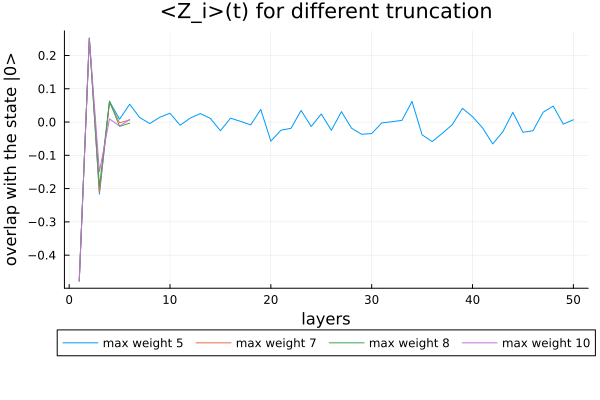

In [48]:
p = plot(title="<Z_i>(t) for different truncation", xlabel="layers", ylabel="overlap with the state |0>")

for (i, overlap) in enumerate(reverse(overlap_max_weight))
    plot!(p, 1:length(overlap), overlap, label="max weight $(max_weight_list[i])")
end
plot!(legend=:outerbottom, legendcolumns=length(overlap_max_weight))

display(p)



---

### Observation

We observe that for a maximum weight below the number of Qubits, our method no longer correctly simulates a quantum state, $\sum_\alpha |c_\alpha|^2$ deviates from 1.

This seems consistent with the type of circuit through which we propagate our observable.
Indeed, a circuit composed of random gates creates a lot of correlation between the qubits. Consequently, a max weight that is too small avoids strong correlations and thus takes us drastically away from the exact physical state, which is highly correlated.

---

## 4.2 Minimum absolute coefficient

In [39]:
# the truncations
max_weight = nqubits
min_abs_coeff_list = range(1e-4, 1e-8, 3)

overlap_min_min_abs_coeff = Vector[]
for min_abs_coeff in min_abs_coeff_list
    println("Min abs coefficient: ",min_abs_coeff)
    pauli_sum, result = propagate_layerbylayer(circuit, observable, nlayers; max_weight, min_abs_coeff)
    push!(overlap_min_min_abs_coeff, result["overlap"])
end

Min abs coefficient: 0.0001
layer : 0/50 Break
Min abs coefficient: 5.0005e-5
layer : 0/50 complete
layer : 5/50 Break
Min abs coefficient: 1.0e-8
layer : 0/50 complete
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete


---

### Plot and Result

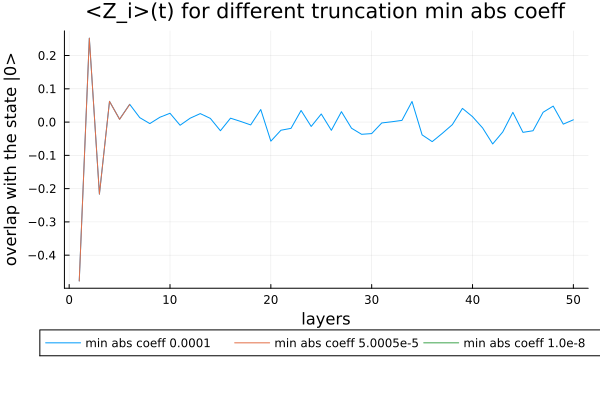

In [47]:
p = plot(title="<Z_i>(t) for different truncation min abs coeff", xlabel="layers", ylabel="overlap with the state |0>")

for (i, overlap) in enumerate(reverse(overlap_min_min_abs_coeff))
    plot!(p, 1:length(overlap), overlap, label="min abs coeff $(min_abs_coeff_list[i])")
end
plot!(legend=:outerbottom, legendcolumns=length(overlap_min_min_abs_coeff))

display(p)

---

### Observation

It is clear that we need a value smaller than $10^{-5}$, so we will use $10^{-8}$.

---

### Summary

For the next simulations, we will use 
- a minimum absolute value of $10^{-8}$,
- a maximum weight equal to the number of qubits.

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- https://cheatsheet.juliadocs.org/
- https://arxiv.org/abs/math-ph/0609050